# 3-2 COMPOSITION DATASET

# 3-2-1  ANN SEQUENTIAL 

In [1]:
# ==========================================================
# 0) IMPORTS
# ==========================================================
import numpy as np
import pandas as pd
import itertools
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, ELU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ==========================================================
# 1) LOAD DATA
# ==========================================================
data = pd.read_csv("composition dataset.csv")
data.columns = data.columns.str.strip()

target_col = [c for c in data.columns if "Hydrate" in c][0]

feature_cols = [col for col in data.columns if col != target_col]

group_cols = [col for col in feature_cols if "Pressure" not in col]

data["group_id"] = data[group_cols].round(3).astype(str).agg("_".join, axis=1)

X = data[feature_cols]
y = data[target_col].values
groups = data["group_id"]

# ==========================================================
# 2) SPLIT
# ==========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups.iloc[train_idx]

gkf = GroupKFold(n_splits=5)

print("Leakage Check:", len(set(groups_train) & set(groups.iloc[test_idx])))

# ==========================================================
# 3) METRICS
# ==========================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rrmse(y_true, y_pred):
    return rmse(y_true, y_pred) / np.mean(y_true)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ==========================================================
# 4) GRID SPACE
# ==========================================================
param_grid = {
    "layers": [(128,64,32,16), (128,64), (256,128,64)],
    "lr": [ 0.001,0.0005],
    "l2": [ 0.0001,1e-3]
}

grid_combinations = list(itertools.product(
    param_grid["layers"],
    param_grid["lr"],
    param_grid["l2"]
))

# ==========================================================
# 5) GRID SEARCH
# ==========================================================
all_results = []
best_score = -np.inf
best_config = None

for i, (layers, lr, reg) in enumerate(grid_combinations):

    print(f"\n===== Trial {i+1}/{len(grid_combinations)} =====")

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train)):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # ================= SCALING =================
        X_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_tr = X_scaler.fit_transform(X_tr)
        X_val = X_scaler.transform(X_val)

        y_tr = y_scaler.fit_transform(y_tr.reshape(-1,1))
        y_val_scaled = y_scaler.transform(y_val.reshape(-1,1))

        # ================= MODEL =================
        model = Sequential()

        for j, units in enumerate(layers):
            if j == 0:
                model.add(Dense(units, kernel_regularizer=l2(reg), input_dim=X_tr.shape[1]))
            else:
                model.add(Dense(units, kernel_regularizer=l2(reg))
)
            model.add(ELU())

        model.add(Dense(1))

        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss="mse"
        )

        early = EarlyStopping(monitor="val_loss", patience=40, restore_best_weights=True)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val_scaled),
            epochs=1500,
            batch_size=16,
            callbacks=[early],
            verbose=0
        )

        # ================= PREDICT =================
        y_pred_scaled = model.predict(X_val)
        y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()

        fold_results.append({
            "Trial": i+1,
            "Fold": fold+1,
            "layers": str(layers),
            "lr": lr,
            "l2": reg,
            "R2": r2_score(y_val, y_pred),
            "RMSE": rmse(y_val, y_pred),
            "MAE": mean_absolute_error(y_val, y_pred),
            "RRMSE": rrmse(y_val, y_pred),
            "MAPE": mape(y_val, y_pred)
        })

    # ================= SAVE FOLDS =================
    fold_df = pd.DataFrame(fold_results)
    fold_df.to_csv(f"ANN_trial_{i+1}_folds.csv", index=False)

    mean_r2 = fold_df["R2"].mean()

    all_results.append({
        "Trial": i+1,
        "layers": str(layers),
        "lr": lr,
        "l2": reg,
        "Mean_R2": mean_r2
    })

    if mean_r2 > best_score:
        best_score = mean_r2
        best_config = (layers, lr, reg)

# ==========================================================
# 6) SAVE GRID SUMMARY
# ==========================================================
summary_df = pd.DataFrame(all_results)
summary_df.to_csv("ANN_grid_summary.csv", index=False)

print("\n BEST CONFIG:", best_config)
print("Best R2:", best_score)

# ==========================================================
# 7) RETRAIN BEST MODEL (CRITICAL )
# ==========================================================
layers, lr, reg = best_config

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1))

best_model = Sequential()

for j, units in enumerate(layers):
    if j == 0:
        best_model.add(Dense(units, kernel_regularizer=l2(reg), input_dim=X_train_scaled.shape[1]))
    else:
        best_model.add(Dense(units, kernel_regularizer=l2(reg)))
    best_model.add(ELU())

best_model.add(Dense(1))

best_model.compile(
    optimizer=Adam(learning_rate=lr),
    loss="mse"
)

best_model.fit(
    X_train_scaled, y_train_scaled,
    epochs=500,
    batch_size=16,
    verbose=0
)

# ==========================================================
# 8) TEST EVALUATION
# ==========================================================
X_test_scaled = X_scaler.transform(X_test)

y_pred_scaled = best_model.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()

test_results = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": rmse(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "RRMSE": rrmse(y_test, y_pred),
    "MAPE": mape(y_test, y_pred)
}

pd.DataFrame([test_results]).to_csv("ANN_test_results.csv", index=False)

# ==========================================================
# 9) SAVE MODEL
# ==========================================================
best_model.save("ANN_best_model.h5")
joblib.dump(X_scaler, "ANN_X_scaler.pkl")
joblib.dump(y_scaler, "ANN_y_scaler.pkl")

print("\n===== FINAL TEST =====")
print(test_results)

print("\nALL DONE ✔")

Leakage Check: 0

===== Trial 1/12 =====
7/7 [==============================] - 0s 4ms/step

===== Trial 2/12 =====
7/7 [==============================] - 0s 3ms/step

===== Trial 3/12 =====
7/7 [==============================] - 0s 5ms/step

===== Trial 4/12 =====
7/7 [==============================] - 0s 3ms/step

===== Trial 5/12 =====
7/7 [==============================] - 0s 0s/step

===== Trial 6/12 =====
7/7 [==============================] - 0s 0s/step

===== Trial 7/12 =====
7/7 [==============================] - 0s 3ms/step

===== Trial 8/12 =====
7/7 [==============================] - 0s 2ms/step

===== Trial 9/12 =====
7/7 [==============================] - 0s 2ms/step

===== Trial 10/12 =====
7/7 [==============================] - 0s 3ms/step

===== Trial 11/12 =====
7/7 [==============================] - 0s 3ms/step

===== Trial 12/12 =====
7/7 [==============================] - 0s 3ms/step

🔥 BEST CONFIG: ((128, 64, 32, 16), 0.0005, 0.0001)
Best R2: 0.9834496260411211
9/

##  3-2-1-1 BEST ANN MODEL SAVED, TIME, MEMORY

In [26]:
# ==========================================================
# ANN FINAL MODEL
# BEST CONFIG:
# Layers = (256,128,64)
# Learning Rate = 0.001
# L2 = 0.001
#
# OUTPUTS:
# - ANN_best_model.h5
# - ANN_X_scaler.pkl
# - ANN_y_scaler.pkl
# - ANN_Final_Summary.csv
#
# REPORTS:
# - Test Metrics
# - Training Time
# - Inference Time
# - Model Size
# - Parameter Count
# ==========================================================

import os
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, ELU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# ==========================================================
# LOAD DATA
# ==========================================================

data = pd.read_excel("composition_dataset_clean.xlsx")

data.columns = data.columns.str.strip()

# ==========================================================
# TARGET
# ==========================================================

target_col = [
    c for c in data.columns
    if "Hydrate" in c
][0]

feature_cols = [
    c for c in data.columns
    if c != target_col
]
# ==========================================================
# BEST HYPERPARAMETERS
# ==========================================================

LAYERS = (128,64,32,16)

LEARNING_RATE = 0.0005

L2_REG = 0.0001
# ==========================================================
# GROUPING
# ==========================================================

group_cols = [
    c for c in feature_cols
    if "Pressure" not in c
]

data["group_id"] = (
    data[group_cols]
    .round(3)
    .astype(str)
    .agg("_".join, axis=1)
)

X = data[feature_cols]

y = data[target_col].values

groups = data["group_id"]

# ==========================================================
# GROUP SPLIT
# ==========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

groups_train = groups.iloc[train_idx]
groups_test  = groups.iloc[test_idx]

print("="*60)
print("LEAKAGE CHECK")
print("="*60)

print(
    len(
        set(groups_train)
        &
        set(groups_test)
    )
)
# ==========================================================
# CROSS VALIDATION (GENERALIZATION CHECK)
# ==========================================================

from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

cv_scores = []

print("\n" + "="*60)
print("5-FOLD GROUP CROSS VALIDATION")
print("="*60)

for fold, (tr_idx, val_idx) in enumerate(
    gkf.split(X_train, y_train, groups_train)
):

    print(f"Fold {fold+1}/5")

    X_tr = X_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train[tr_idx]
    y_val = y_train[val_idx]

    # ---------------- Scaling ----------------

    X_scaler_cv = StandardScaler()
    y_scaler_cv = StandardScaler()

    X_tr_scaled = X_scaler_cv.fit_transform(X_tr)
    X_val_scaled = X_scaler_cv.transform(X_val)

    y_tr_scaled = y_scaler_cv.fit_transform(
        y_tr.reshape(-1,1)
    )

    # ---------------- Model ----------------

    cv_model = Sequential()

    for i, units in enumerate(LAYERS):

        if i == 0:

            cv_model.add(
                Dense(
                    units,
                    input_dim=X_tr_scaled.shape[1],
                    kernel_regularizer=l2(L2_REG)
                )
            )

        else:

            cv_model.add(
                Dense(
                    units,
                    kernel_regularizer=l2(L2_REG)
                )
            )

        cv_model.add(ELU())

    cv_model.add(Dense(1))

    cv_model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="mse"
    )

    cv_model.fit(
        X_tr_scaled,
        y_tr_scaled,
        epochs=500,
        batch_size=16,
        verbose=0
    )

    y_pred_cv_scaled = cv_model.predict(
        X_val_scaled,
        verbose=0
    )

    y_pred_cv = y_scaler_cv.inverse_transform(
        y_pred_cv_scaled
    ).flatten()

    fold_r2 = r2_score(
        y_val,
        y_pred_cv
    )

    cv_scores.append(fold_r2)

    print(
        f"Fold {fold+1} R2 = {fold_r2:.6f}"
    )

# ==========================================================
# CV RESULTS
# ==========================================================

CV_R2_MEAN = np.mean(cv_scores)

CV_R2_STD = np.std(cv_scores)

print("\n" + "="*60)
print("CROSS VALIDATION RESULTS")
print("="*60)

print(f"CV Mean R2 : {CV_R2_MEAN:.6f}")
print(f"CV Std R2  : {CV_R2_STD:.6f}")
# ==========================================================
# SCALING
# ==========================================================

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train
)

X_test_scaled = X_scaler.transform(
    X_test
)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1,1)
)

# ==========================================================
# BEST HYPERPARAMETERS
# ==========================================================

LAYERS = (128,64,32,16)

LEARNING_RATE = 0.0005

L2_REG = 0.0001

# ==========================================================
# BUILD MODEL
# ==========================================================

model = Sequential()

for i, units in enumerate(LAYERS):

    if i == 0:

        model.add(
            Dense(
                units,
                input_dim=X_train_scaled.shape[1],
                kernel_regularizer=l2(L2_REG)
            )
        )

    else:

        model.add(
            Dense(
                units,
                kernel_regularizer=l2(L2_REG)
            )
        )

    model.add(
        ELU()
    )

model.add(
    Dense(1)
)

model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse"
)

# ==========================================================
# TRAINING TIME
# ==========================================================

print("\nTraining ANN...")

start_train = time.time()

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=500,
    batch_size=16,
    verbose=0
)

training_time = (
    time.time()
    -
    start_train
)

# ==========================================================
# PREDICTION
# ==========================================================

y_pred_scaled = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = y_scaler.inverse_transform(
    y_pred_scaled
).flatten()

# ==========================================================
# METRICS
# ==========================================================

def rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

def rrmse(y_true, y_pred):
    return (
        rmse(y_true,y_pred)
        /
        np.mean(y_true)
    )

def mape(y_true, y_pred):
    return (
        np.mean(
            np.abs(
                (y_true-y_pred)
                /
                y_true
            )
        )
        *100
    )

R2 = r2_score(
    y_test,
    y_pred
)

RMSE = rmse(
    y_test,
    y_pred
)

MAE = mean_absolute_error(
    y_test,
    y_pred
)

RRMSE = rrmse(
    y_test,
    y_pred
)

MAPE = mape(
    y_test,
    y_pred
)

# ==========================================================
# SAVE MODEL
# ==========================================================

model.save(
    "ANN11_best_model.h5"
)

joblib.dump(
    X_scaler,
    "ANN11_X_scaler.pkl"
)

joblib.dump(
    y_scaler,
    "ANN11_y_scaler.pkl"
)

# ==========================================================
# MODEL SIZE
# ==========================================================

model_size_mb = (
    os.path.getsize(
        "ANN11_best_model.h5"
    )
    /
    (1024**2)
)

# ==========================================================
# PARAMETER COUNT
# ==========================================================

parameter_count = (
    model.count_params()
)

# ==========================================================
# INFERENCE TIME
# ==========================================================

sample = X_test_scaled[:1]

start_inf = time.time()

model.predict(
    sample,
    verbose=0
)

inference_time_ms = (
    (
        time.time()
        -
        start_inf
    )
    *1000
)

# ==========================================================
# SUMMARY TABLE
# ==========================================================

summary = pd.DataFrame([{

    "Model":
        "ANN",

    "Architecture":
        "256-128-64",

    "Learning_Rate":
        LEARNING_RATE,

    "L2":
        L2_REG,

    "R2":
        R2,
    "CV_R2_Mean":
        CV_R2_MEAN,
    "CV_R2_STD":
        CV_R2_STD,
    "RMSE":
        RMSE,

    "MAE":
        MAE,

    "RRMSE":
        RRMSE,

    "MAPE":
        MAPE,

    "Training_Time_sec":
        training_time,

    "Inference_Time_ms":
        inference_time_ms,

    "Parameters":
        parameter_count,

    "Model_Size_MB":
        model_size_mb,

    "Model_File":
        "ANN_best_model.h5"

}])

summary.to_csv(
    "ANN11_Final_Summary.csv",
    index=False
)

# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\n" + "="*60)
print("BEST ANN MODEL REPORT")
print("="*60)

print(f"Architecture      : {LAYERS}")
print(f"Learning Rate     : {LEARNING_RATE}")
print(f"L2 Regularization : {L2_REG}")

print("\nMETRICS")

print(f"R2      : {R2:.6f}")
print(f"CV Mean R2 : {CV_R2_MEAN:.6f}")
print(f"CV Std R2  : {CV_R2_STD:.6f}")
print(f"RMSE    : {RMSE:.6f}")
print(f"MAE     : {MAE:.6f}")
print(f"RRMSE   : {RRMSE:.6f}")
print(f"MAPE %  : {MAPE:.6f}")

print("\nMODEL INFO")

print(f"Training Time (s) : {training_time:.2f}")
print(f"Inference (ms)    : {inference_time_ms:.4f}")
print(f"Parameters        : {parameter_count:,}")
print(f"Model Size (MB)   : {model_size_mb:.4f}")

print("\nFILES")

print("ANN1_best_model.h5")
print("ANN1_X_scaler.pkl")
print("ANN1_y_scaler.pkl")
print("ANN_Final_Summary.csv")

print("\nDONE")

LEAKAGE CHECK
0

5-FOLD GROUP CROSS VALIDATION
Fold 1/5
Fold 1 R2 = 0.969091
Fold 2/5
Fold 2 R2 = 0.976636
Fold 3/5
Fold 3 R2 = 0.952741
Fold 4/5
Fold 4 R2 = 0.926504
Fold 5/5
Fold 5 R2 = 0.954282

CROSS VALIDATION RESULTS
CV Mean R2 : 0.955851
CV Std R2  : 0.017209

Training ANN...

BEST ANN MODEL REPORT
Architecture      : (128, 64, 32, 16)
Learning Rate     : 0.0005
L2 Regularization : 0.0001

METRICS
R2      : 0.987411
CV Mean R2 : 0.955851
CV Std R2  : 0.017209
RMSE    : 1.626887
MAE     : 0.791617
RRMSE   : 0.005762
MAPE %  : 0.298081

MODEL INFO
Training Time (s) : 143.62
Inference (ms)    : 210.8583
Parameters        : 12,801
Model Size (MB)   : 0.1956

FILES
ANN1_best_model.h5
ANN1_X_scaler.pkl
ANN1_y_scaler.pkl
ANN_Final_Summary.csv

DONE


# 3-2-1-2 ANN EXTERNAL VALIDATION

In [1]:
# ==========================================================
# EXTERNAL VALIDATION
# SAMPLE 11

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import load_model
import joblib

# ==========================================================
# LOAD ANN MODEL
# ==========================================================

ann_model = load_model(
    "ANN11_best_model.h5",
    compile=False
)

X_scaler = joblib.load(
    "ANN11_X_scaler.pkl"
)

y_scaler = joblib.load(
    "ANN11_y_scaler.pkl"
)


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


Pc = {
    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0
}

# ==========================================================
# SAMPLE 11 COMPOSITION
# ==========================================================

CH4  = 77.61
CO2  = 6.14
C2   = 8.81
C3   = 3.37
iC4  = 0.75
nC4  = 1.33
iC5  = 0.44
nC5  = 0.69
C6   = 0.86
C7   = 0.00

Water = 0.0
N2    = 0.0
H2S   = 0.0

# ==========================================================
# SAMPLE 11 EXPERIMENTAL
# ==========================================================

pressure = np.array([
    590.00,
    702.22,
    814.44,
    926.67,
    1038.89,
    1151.11,
    1263.33,
    1375.56,
    1487.78,
    1600.00
])


# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    287.94,
    289.30,
    290.32,
    291.09,
    291.66,
    292.12,
    292.54,
    292.98,
    293.53,
    294.26
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97



# ==========================================================
# CALCULATE PPC
# ==========================================================

PPC = (
      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]
)/100

PR = pressure / PPC

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water": [0]*len(pressure),

    "Methane": [CH4]*len(pressure),
    "Ethane": [C2]*len(pressure),
    "Propane": [C3]*len(pressure),
    "Isobutane": [iC4]*len(pressure),
    "Butane": [nC4]*len(pressure),
    "Isopentane": [iC5]*len(pressure),
    "Pentane": [nC5]*len(pressure),
    "Hexane": [C6]*len(pressure),
    "Heptane": [C7]*len(pressure),

    "Carbon Dioxide": [CO2]*len(pressure),

    "SPECIFIC GRAVITY": [SP_GR]*len(pressure),

    "Pressure (psia)": pressure,

    "PR": PR
})

# ==========================================================
# SCALE INPUT
# ==========================================================

X_new_scaled = X_scaler.transform(
    X_new
)

# ==========================================================
# ANN PREDICTION
# ==========================================================

ann_pred_scaled = ann_model.predict(
    X_new_scaled,
    verbose=0
)

ANN_pred = y_scaler.inverse_transform(
    ann_pred_scaled
).flatten()
# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

ANN_rmse,ANN_mae,ANN_rrmse = calc_metrics(
    experimental,
    ANN_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "ANN Prediction (K)": ANN_pred

})

print(results)



metrics = pd.DataFrame({

    "Method":[
        "ANN11"
    ],

    "RMSE":[
        ANN_rmse
    ],

    "MAE":[
        ANN_mae
    ],

    "RRMSE (%)":[
        ANN_rrmse
    ]

})

print(metrics)
print("\nMetrics\n")
print(metrics)

results.to_excel(
    "Sample11_ANN_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_ANN_Metrics.xlsx",
    index=False
)

   Pressure (psia)  Experimental (K)  ANN Prediction (K)
0           590.00            287.94          286.661072
1           702.22            289.30          287.963928
2           814.44            290.32          289.014771
3           926.67            291.09          289.876282
4          1038.89            291.66          290.597839
5          1151.11            292.12          291.217743
6          1263.33            292.54          291.762695
7          1375.56            292.98          292.252075
8          1487.78            293.53          292.697968
9          1600.00            294.26          293.109070
  Method      RMSE       MAE  RRMSE (%)
0  ANN11  1.081237  1.058656   0.370828

Metrics

  Method      RMSE       MAE  RRMSE (%)
0  ANN11  1.081237  1.058656   0.370828


In [52]:
# ==========================================================
# EXTERNAL VALIDATION
# LAVAN-3 GAS WELL

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import load_model
import joblib

# ==========================================================
# LOAD ANN MODEL
# ==========================================================

ann_model = load_model(
    "ANN11_best_model.h5",
    compile=False
)

X_scaler = joblib.load(
    "ANN11_X_scaler.pkl"
)

y_scaler = joblib.load(
    "ANN11_y_scaler.pkl"
)


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


Pc = {
    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0
}

# ==========================================================
# lavan#3 GAS COMPOSITION
# ==========================================================

CH4 = 89.19
CO2 = 4.44
C2  = 4.24
C3  = 1.14
iC4 = 0.28
nC4 = 0.30
iC5 = 0.15
nC5 = 0.10
C6  = 0.09
C7  = 0.07

N2  = 0.0
H2S = 0.0
Water = 0.0

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
    690.00,
    878.33,
    1066.67,
    1255.00,
    1443.33,
    1631.67,
    1820.00,
    2008.33,
    2196.67,
    2385.00,
    2573.33,
    2761.67,
    2950.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    285.90,
    287.32,
    288.52,
    289.64,
    290.60,
    291.37,
    291.98,
    292.48,
    292.90,
    293.30,
    293.69,
    294.07,
    294.45
])
# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    285.87,
    287.59,
    288.87,
    289.86,
    290.67,
    291.36,
    291.99,
    292.57,
    293.11,
    293.64,
    294.16,
    294.66,
    295.14
])


# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97



# ==========================================================
# CALCULATE PPC
# ==========================================================

PPC = (
      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]
)/100

PR = pressure / PPC

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water": [0]*len(pressure),

    "Methane": [CH4]*len(pressure),
    "Ethane": [C2]*len(pressure),
    "Propane": [C3]*len(pressure),
    "Isobutane": [iC4]*len(pressure),
    "Butane": [nC4]*len(pressure),
    "Isopentane": [iC5]*len(pressure),
    "Pentane": [nC5]*len(pressure),
    "Hexane": [C6]*len(pressure),
    "Heptane": [C7]*len(pressure),

    "Carbon Dioxide": [CO2]*len(pressure),

    "SPECIFIC GRAVITY": [SP_GR]*len(pressure),

    "Pressure (psia)": pressure,

    "PR": PR
})

# ==========================================================
# SCALE INPUT
# ==========================================================

X_new_scaled = X_scaler.transform(
    X_new
)

# ==========================================================
# ANN PREDICTION
# ==========================================================

ann_pred_scaled = ann_model.predict(
    X_new_scaled,
    verbose=0
)

ANN_pred = y_scaler.inverse_transform(
    ann_pred_scaled
).flatten()
# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

ANN_rmse,ANN_mae,ANN_rrmse = calc_metrics(
    experimental,
    ANN_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "ANN Prediction (K)": ANN_pred

})

print(results)



metrics = pd.DataFrame({

    "Method":[
        "ANN11"
    ],

    "RMSE":[
        ANN_rmse
    ],

    "MAE":[
        ANN_mae
    ],

    "RRMSE (%)":[
        ANN_rrmse
    ]

})

print(metrics)
print("\nMetrics\n")
print(metrics)

results.to_excel(
    "lavan_ANN_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "lavan_ANN_Metrics.xlsx",
    index=False
)

    Pressure (psia)  Experimental (K)  ANN Prediction (K)
0            690.00            285.90          286.522552
1            878.33            287.32          288.097076
2           1066.67            288.52          289.203400
3           1255.00            289.64          290.042664
4           1443.33            290.60          290.743988
5           1631.67            291.37          291.363190
6           1820.00            291.98          291.928101
7           2008.33            292.48          292.456818
8           2196.67            292.90          292.960022
9           2385.00            293.30          293.444214
10          2573.33            293.69          293.913849
11          2761.67            294.07          294.371857
12          2950.00            294.45          294.820404
  Method      RMSE       MAE  RRMSE (%)
0  ANN11  0.387043  0.293224   0.132891

Metrics

  Method      RMSE       MAE  RRMSE (%)
0  ANN11  0.387043  0.293224   0.132891


In [51]:
# ==========================================================
# EXTERNAL VALIDATION
# SALMAN GAS WELL

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import load_model
import joblib

# ==========================================================
# LOAD ANN MODEL
# ==========================================================

ann_model = load_model(
    "ANN11_best_model.h5",
    compile=False
)

X_scaler = joblib.load(
    "ANN11_X_scaler.pkl"
)

y_scaler = joblib.load(
    "ANN11_y_scaler.pkl"
)


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


Pc = {
    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0
}

# ==========================================================
# GAS COMPOSITION (SALMAN)
# ==========================================================

CH4 = 74.10
CO2 = 3.95
C2  = 10.82
C3  = 6.70
iC4 = 0.94
nC4 = 2.04
iC5 = 0.53
nC5 = 0.58
C6  = 0.25
C7  = 0.08

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
     700.00,
     891.67,
    1083.33,
    1275.00,
    1466.67,
    1658.33,
    1850.00,
    2041.67,
    2233.33,
    2425.00,
    2616.67,
    2808.33,
    3000.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    289.86,
    291.93,
    293.02,
    293.68,
    294.26,
    294.79,
    295.26,
    295.68,
    296.07,
    296.44,
    296.79,
    297.13,
    297.49
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97



# ==========================================================
# CALCULATE PPC
# ==========================================================

PPC = (
      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]
)/100

PR = pressure / PPC

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water": [0]*len(pressure),

    "Methane": [CH4]*len(pressure),
    "Ethane": [C2]*len(pressure),
    "Propane": [C3]*len(pressure),
    "Isobutane": [iC4]*len(pressure),
    "Butane": [nC4]*len(pressure),
    "Isopentane": [iC5]*len(pressure),
    "Pentane": [nC5]*len(pressure),
    "Hexane": [C6]*len(pressure),
    "Heptane": [C7]*len(pressure),

    "Carbon Dioxide": [CO2]*len(pressure),

    "SPECIFIC GRAVITY": [SP_GR]*len(pressure),

    "Pressure (psia)": pressure,

    "PR": PR
})

# ==========================================================
# SCALE INPUT
# ==========================================================

X_new_scaled = X_scaler.transform(
    X_new
)

# ==========================================================
# ANN PREDICTION
# ==========================================================

ann_pred_scaled = ann_model.predict(
    X_new_scaled,
    verbose=0
)

ANN_pred = y_scaler.inverse_transform(
    ann_pred_scaled
).flatten()
# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

ANN_rmse,ANN_mae,ANN_rrmse = calc_metrics(
    experimental,
    ANN_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "ANN Prediction (K)": ANN_pred

})

print(results)



metrics = pd.DataFrame({

    "Method":[
        "ANN11"
    ],

    "RMSE":[
        ANN_rmse
    ],

    "MAE":[
        ANN_mae
    ],

    "RRMSE (%)":[
        ANN_rrmse
    ]

})

print(metrics)
print("\nMetrics salman\n")
print(metrics)


    Pressure (psia)  Experimental (K)  ANN Prediction (K)
0            700.00            289.86          288.036926
1            891.67            291.93          289.838501
2           1083.33            293.02          291.133911
3           1275.00            293.68          292.117096
4           1466.67            294.26          292.914185
5           1658.33            294.79          293.603760
6           1850.00            295.26          294.229767
7           2041.67            295.68          294.811676
8           2233.33            296.07          295.358490
9           2425.00            296.44          295.879028
10          2616.67            296.79          296.378967
11          2808.33            297.13          296.862183
12          3000.00            297.49          297.331665
  Method      RMSE       MAE  RRMSE (%)
0  ANN11  1.234703  1.069527   0.418827

Metrics salman

  Method      RMSE       MAE  RRMSE (%)
0  ANN11  1.234703  1.069527   0.418827


# 3-2-2 GPR grouping

In [4]:
# =========================
# 0) IMPORTS
# =========================
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# =========================
# 1) LOAD DATA
# =========================
data = pd.read_csv("composition dataset.csv")  # بدون sep
feature_cols = [col for col in data.columns if col != "Hydrate Temperature (K)"]

data["group_id"] = data[feature_cols].round(3).astype(str).agg("_".join, axis=1)

X = data.drop(["Hydrate Temperature (K)", "group_id"], axis=1).values
y = data["Hydrate Temperature (K)"].values
groups = data["group_id"]

# =========================
# 2) SPLIT
# =========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups.iloc[train_idx]

gkf = GroupKFold(n_splits=5)

print("Leakage check:", len(set(groups_train) & set(groups.iloc[test_idx])))

# =========================
# 3) METRICS
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rrmse(y_true, y_pred):
    return rmse(y_true, y_pred) / np.mean(y_true)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# =========================
# 4) CUSTOM GPR PIPELINE
# =========================
class GPRPipeline(BaseEstimator, RegressorMixin):

    def __init__(self, n_clusters=300, alpha=1e-5):
        self.n_clusters = n_clusters
        self.alpha = alpha

    def fit(self, X, y):

        self.X_scaler = StandardScaler()
        self.y_scaler = StandardScaler()

        X_scaled = self.X_scaler.fit_transform(X)
        y_scaled = self.y_scaler.fit_transform(y.reshape(-1,1)).ravel()

        n_clusters = min(self.n_clusters, len(X_scaled))

        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(X_scaled)

        centers = kmeans.cluster_centers_
        indices = []

        for c in centers:
            distances = np.linalg.norm(X_scaled - c, axis=1)
            indices.append(np.argmin(distances))

        X_sub = X_scaled[indices]
        y_sub = y_scaled[indices]

        kernel = C(1.0) * Matern(nu=1.5) + WhiteKernel()

        self.model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=self.alpha,
            normalize_y=False,
            n_restarts_optimizer=3
        )

        self.model.fit(X_sub, y_sub)
        return self

    def predict(self, X):
        X_scaled = self.X_scaler.transform(X)
        y_pred_scaled = self.model.predict(X_scaled)
        return self.y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

# =========================
# 5) GRID SEARCH
# =========================
gpr_model = GPRPipeline()

param_grid = {
    "n_clusters": [200, 300, 400],
    "alpha": [1e-5, 1e-4]
}

grid = GridSearchCV(
    gpr_model,
    param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train, groups=groups_train)

# =========================
# SAVE GRID RESULTS
# =========================
pd.DataFrame(grid.cv_results_).to_csv("GPR_GRID_SEARCH.csv", index=False)

# =========================
# BEST MODEL
# =========================
best_model = grid.best_estimator_
joblib.dump(best_model, "GPR_best_model.pkl")

print("Best Params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# =========================
# 6) GROUPED FOLD RESULTS (FULL)
# =========================
fold_results = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train)):

    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    best_model.fit(X_tr, y_tr)
    y_pred = best_model.predict(X_val)

    fold_results.append({
        "Fold": fold+1,
        "R2": r2_score(y_val, y_pred),
        "RMSE": rmse(y_val, y_pred),
        "MAE": mean_absolute_error(y_val, y_pred),
        "RRMSE": rrmse(y_val, y_pred),
        "MAPE (%)": mape(y_val, y_pred)
    })

fold_df = pd.DataFrame(fold_results)
fold_df.to_csv("GPR_GROUPED_FOLDS.csv", index=False)

print("\nMean CV Results:")
print(fold_df.mean())

# =========================
# 7) FINAL TEST
# =========================
y_pred = best_model.predict(X_test)

test_results = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": rmse(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "RRMSE": rrmse(y_test, y_pred),
    "MAPE (%)": mape(y_test, y_pred)
}

pd.DataFrame([test_results]).to_csv("GPR_TEST_RESULTS.csv", index=False)

print("\n===== FINAL TEST =====")
print(test_results)

print("\nALL FILES SAVED ✔")

Leakage check: 0


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Best Params: {'alpha': 1e-05, 'n_clusters': 400}
Best CV R2: 0.8534180639493087


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the va


Mean CV Results:
Fold        3.000000
R2          0.853418
RMSE        5.732192
MAE         2.976248
RRMSE       0.020313
MAPE (%)    1.141615
dtype: float64

===== FINAL TEST =====
{'R2': 0.8646029824287991, 'RMSE': 5.123419487225822, 'MAE': 2.643967657403965, 'RRMSE': 0.018115879672187016, 'MAPE (%)': 1.006136708220418}

ALL FILES SAVED ✔


## 3-2-2-1 GPR BEST MODEL SAVED MODEL, TIME, MEMORY

In [1]:
# ==========================================================
# GPR FINAL MODEL
# WITH:
# - GroupShuffleSplit
# - GroupKFold Cross Validation
# - Grid Search
# - CV Mean R2
# - CV Std R2
# - Training Time
# - Inference Time
# - Model Size
# - Save Best Model
# ==========================================================

import os
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    WhiteKernel,
    ConstantKernel as C
)

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD DATA
# ==========================================================

data = pd.read_excel("composition_dataset_clean.xlsx")

data.columns = data.columns.str.strip()

target_col = "Hydrate Temperature (K)"

feature_cols = [
    col for col in data.columns
    if col != target_col
]

# ==========================================================
# GROUPING
# ==========================================================

data["group_id"] = (
    data[feature_cols]
    .round(3)
    .astype(str)
    .agg("_".join, axis=1)
)

X = data[feature_cols].values

y = data[target_col].values

groups = data["group_id"]

# ==========================================================
# GROUP SPLIT
# ==========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups
    )
)

X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

groups_train = groups.iloc[train_idx]
groups_test  = groups.iloc[test_idx]

print("="*60)
print("LEAKAGE CHECK")
print("="*60)

print(
    len(
        set(groups_train)
        &
        set(groups_test)
    )
)

# ==========================================================
# METRICS
# ==========================================================

def rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

def rrmse(y_true, y_pred):
    return (
        rmse(y_true, y_pred)
        /
        np.mean(y_true)
    )

def mape(y_true, y_pred):
    return (
        np.mean(
            np.abs(
                (y_true - y_pred)
                /
                y_true
            )
        )
        * 100
    )

# ==========================================================
# CUSTOM GPR
# ==========================================================

class GPRPipeline(
    BaseEstimator,
    RegressorMixin
):

    def __init__(
        self,
        n_clusters=300,
        alpha=1e-5
    ):

        self.n_clusters = n_clusters
        self.alpha = alpha

    def fit(
        self,
        X,
        y
    ):

        self.X_scaler = StandardScaler()

        self.y_scaler = StandardScaler()

        X_scaled = self.X_scaler.fit_transform(X)

        y_scaled = self.y_scaler.fit_transform(
            y.reshape(-1,1)
        ).ravel()

        n_clusters = min(
            self.n_clusters,
            len(X_scaled)
        )

        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=42
        )

        kmeans.fit(
            X_scaled
        )

        centers = kmeans.cluster_centers_

        indices = []

        for c in centers:

            distances = np.linalg.norm(
                X_scaled - c,
                axis=1
            )

            indices.append(
                np.argmin(distances)
            )

        X_sub = X_scaled[indices]

        y_sub = y_scaled[indices]

        kernel = (
            C(1.0)
            *
            Matern(nu=1.5)
            +
            WhiteKernel()
        )

        self.model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=self.alpha,
            normalize_y=False,
            n_restarts_optimizer=3
        )

        self.model.fit(
            X_sub,
            y_sub
        )

        return self

    def predict(
        self,
        X
    ):

        X_scaled = self.X_scaler.transform(X)

        y_pred_scaled = self.model.predict(
            X_scaled
        )

        return self.y_scaler.inverse_transform(
            y_pred_scaled.reshape(-1,1)
        ).ravel()

# ==========================================================
# GRID SEARCH
# ==========================================================

gpr = GPRPipeline()

param_grid = {

    "n_clusters": [
        400
    ],

    "alpha": [
        1e-5
    ]
}

gkf = GroupKFold(
    n_splits=5
)

grid = GridSearchCV(
    estimator=gpr,
    param_grid=param_grid,
    scoring="r2",
    cv=gkf,
    n_jobs=-1,
    return_train_score=True
)

print("\nGRID SEARCH STARTED...")

grid.fit(
    X_train,
    y_train,
    groups=groups_train
)

# ==========================================================
# BEST PARAMETERS
# ==========================================================

best_model = grid.best_estimator_

cv_mean_r2 = grid.best_score_

cv_std_r2 = (
    pd.DataFrame(
        grid.cv_results_
    )
    .loc[
        grid.best_index_,
        "std_test_score"
    ]
)

print("\nBEST PARAMETERS")
print(grid.best_params_)

print(
    f"CV Mean R2 : {cv_mean_r2:.6f}"
)

print(
    f"CV Std R2  : {cv_std_r2:.6f}"
)

# ==========================================================
# TRAIN BEST MODEL
# ==========================================================

print("\nTraining Best GPR...")

start_train = time.time()

best_model.fit(
    X_train,
    y_train
)

training_time = (
    time.time()
    -
    start_train
)

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(
    best_model,
    "GPR1_best_model.pkl"
)

# ==========================================================
# MODEL SIZE
# ==========================================================

model_size_mb = (
    os.path.getsize(
        "GPR1_best_model.pkl"
    )
    /
    (1024**2)
)

# ==========================================================
# INFERENCE TIME
# ==========================================================

sample = X_test[:1]

start_inf = time.time()

best_model.predict(
    sample
)

inference_time_ms = (
    (
        time.time()
        -
        start_inf
    )
    *1000
)

# ==========================================================
# TEST EVALUATION
# ==========================================================

y_pred = best_model.predict(
    X_test
)

R2 = r2_score(
    y_test,
    y_pred
)

RMSE = rmse(
    y_test,
    y_pred
)

MAE = mean_absolute_error(
    y_test,
    y_pred
)

RRMSE = rrmse(
    y_test,
    y_pred
)

MAPE = mape(
    y_test,
    y_pred
)

generalization_gap = (
    R2
    -
    cv_mean_r2
)

# ==========================================================
# SUMMARY
# ==========================================================

summary = pd.DataFrame([{

    "Model":
        "GPR",

    "n_clusters":
        grid.best_params_["n_clusters"],

    "alpha":
        grid.best_params_["alpha"],

    "R2":
        R2,

    "CV_Mean_R2":
        cv_mean_r2,

    "CV_Std_R2":
        cv_std_r2,

    "Generalization_Gap":
        generalization_gap,

    "RMSE":
        RMSE,

    "MAE":
        MAE,

    "RRMSE":
        RRMSE,

    "MAPE":
        MAPE,

    "Training_Time_sec":
        training_time,

    "Inference_Time_ms":
        inference_time_ms,

    "Model_Size_MB":
        model_size_mb

}])

summary.to_csv(
    "GPR_Final_Summary.csv",
    index=False
)

# ==========================================================
# REPORT
# ==========================================================

print("\n")
print("="*60)
print("BEST GPR MODEL REPORT")
print("="*60)

print(
    f"n_clusters : {grid.best_params_['n_clusters']}"
)

print(
    f"alpha      : {grid.best_params_['alpha']}"
)

print("\nMETRICS")

print(
    f"R2      : {R2:.6f}"
)

print(
    f"RMSE    : {RMSE:.6f}"
)

print(
    f"MAE     : {MAE:.6f}"
)

print(
    f"RRMSE   : {RRMSE:.6f}"
)

print(
    f"MAPE %  : {MAPE:.6f}"
)

print("\nCROSS VALIDATION")

print(
    f"CV Mean R2 : {cv_mean_r2:.6f}"
)

print(
    f"CV Std R2  : {cv_std_r2:.6f}"
)

print(
    f"Generalization Gap : {generalization_gap:.6f}"
)

print("\nMODEL INFO")

print(
    f"Training Time (s) : {training_time:.2f}"
)

print(
    f"Inference (ms)    : {inference_time_ms:.4f}"
)

print(
    f"Model Size (MB)   : {model_size_mb:.4f}"
)

print("\nFILES")

print("GPR1_best_model.pkl")
print("GPR_Final_Summary.csv")

print("\nDONE")

LEAKAGE CHECK
0

GRID SEARCH STARTED...


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(



BEST PARAMETERS
{'alpha': 1e-05, 'n_clusters': 400}
CV Mean R2 : 0.828967
CV Std R2  : 0.012761

Training Best GPR...


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(




BEST GPR MODEL REPORT
n_clusters : 400
alpha      : 1e-05

METRICS
R2      : 0.816748
RMSE    : 5.536109
MAE     : 2.415994
RRMSE   : 0.019522
MAPE %  : 0.930457

CROSS VALIDATION
CV Mean R2 : 0.828967
CV Std R2  : 0.012761
Generalization Gap : -0.012219

MODEL INFO
Training Time (s) : 7.69
Inference (ms)    : 0.0000
Model Size (MB)   : 1.2745

FILES
GPR1_best_model.pkl
GPR_Final_Summary.csv

DONE


## 3-2-2-2 GPR EXTERNAL VALIDATION

In [7]:
# ==========================================================
# EXTERNAL VALIDATION
# SAMPLE 11 GAS WELL

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

GPR_model = joblib.load("GPR1_best_model.pkl")


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


Pc = {
    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0
}

# ==========================================================
# SAMPLE 11 COMPOSITION
# ==========================================================

CH4  = 77.61
CO2  = 6.14
C2   = 8.81
C3   = 3.37
iC4  = 0.75
nC4  = 1.33
iC5  = 0.44
nC5  = 0.69
C6   = 0.86
C7   = 0.00

Water = 0.0
N2    = 0.0
H2S   = 0.0

# ==========================================================
# SAMPLE 11 EXPERIMENTAL
# ==========================================================

pressure = np.array([
    590.00,
    702.22,
    814.44,
    926.67,
    1038.89,
    1151.11,
    1263.33,
    1375.56,
    1487.78,
    1600.00
])


# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    287.94,
    289.30,
    290.32,
    291.09,
    291.66,
    292.12,
    292.54,
    292.98,
    293.53,
    294.26
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97



# ==========================================================
# CALCULATE PPC
# ==========================================================

PPC = (
      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]
)/100

PR = pressure / PPC

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water": [0]*len(pressure),

    "Methane": [CH4]*len(pressure),
    "Ethane": [C2]*len(pressure),
    "Propane": [C3]*len(pressure),
    "Isobutane": [iC4]*len(pressure),
    "Butane": [nC4]*len(pressure),
    "Isopentane": [iC5]*len(pressure),
    "Pentane": [nC5]*len(pressure),
    "Hexane": [C6]*len(pressure),
    "Heptane": [C7]*len(pressure),

    "Carbon Dioxide": [CO2]*len(pressure),

    "SPECIFIC GRAVITY": [SP_GR]*len(pressure),

    "Pressure (psia)": pressure,

    "PR": PR
})

# ==========================================================
# PREDICTIONS
# ==========================================================

GPR_pred = GPR_model.predict(X_new)


# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

GPR_rmse,GPR_mae,GPR_rrmse = calc_metrics(
    experimental,
    GPR_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "GPR Prediction (K)": GPR_pred,

    

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "GPR1"
    ],

    "RMSE":[
        GPR_rmse
    ],

    "MAE":[
        GPR_mae
    ],

    "RRMSE (%)":[
        GPR_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

   Pressure (psia)  Experimental (K)  GPR Prediction (K)
0           590.00            287.94          281.363834
1           702.22            289.30          283.932890
2           814.44            290.32          286.112864
3           926.67            291.09          287.934509
4          1038.89            291.66          289.435222
5          1151.11            292.12          290.656780
6          1263.33            292.54          291.641693
7          1375.56            292.98          292.430995
8          1487.78            293.53          293.062170
9          1600.00            294.26          293.568421

Metrics

  Method      RMSE       MAE  RRMSE (%)
0   GPR1  3.295529  2.560062   1.130255


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [49]:
# ==========================================================
# EXTERNAL VALIDATION
# LAVAN-3 GAS WELL

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

GPR_model = joblib.load("GPR1_best_model.pkl")


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


Pc = {
    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0
}
# ==========================================================
# lavan#3 GAS COMPOSITION
# ==========================================================

CH4 = 89.19
CO2 = 4.44
C2  = 4.24
C3  = 1.14
iC4 = 0.28
nC4 = 0.30
iC5 = 0.15
nC5 = 0.10
C6  = 0.09
C7  = 0.07

N2  = 0.0
H2S = 0.0
Water = 0.0
# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
    690.00,
    878.33,
    1066.67,
    1255.00,
    1443.33,
    1631.67,
    1820.00,
    2008.33,
    2196.67,
    2385.00,
    2573.33,
    2761.67,
    2950.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    285.90,
    287.32,
    288.52,
    289.64,
    290.60,
    291.37,
    291.98,
    292.48,
    292.90,
    293.30,
    293.69,
    294.07,
    294.45
])
# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    285.87,
    287.59,
    288.87,
    289.86,
    290.67,
    291.36,
    291.99,
    292.57,
    293.11,
    293.64,
    294.16,
    294.66,
    295.14
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97



# ==========================================================
# CALCULATE PPC
# ==========================================================

PPC = (
      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]
)/100

PR = pressure / PPC

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water": [0]*len(pressure),

    "Methane": [CH4]*len(pressure),
    "Ethane": [C2]*len(pressure),
    "Propane": [C3]*len(pressure),
    "Isobutane": [iC4]*len(pressure),
    "Butane": [nC4]*len(pressure),
    "Isopentane": [iC5]*len(pressure),
    "Pentane": [nC5]*len(pressure),
    "Hexane": [C6]*len(pressure),
    "Heptane": [C7]*len(pressure),

    "Carbon Dioxide": [CO2]*len(pressure),

    "SPECIFIC GRAVITY": [SP_GR]*len(pressure),

    "Pressure (psia)": pressure,

    "PR": PR
})

# ==========================================================
# PREDICTIONS
# ==========================================================

GPR_pred = GPR_model.predict(X_new)


# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

GPR_rmse,GPR_mae,GPR_rrmse = calc_metrics(
    experimental,
    GPR_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "GPR Prediction (K)": GPR_pred,

    

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "GPR1"
    ],

    "RMSE":[
        GPR_rmse
    ],

    "MAE":[
        GPR_mae
    ],

    "RRMSE (%)":[
        GPR_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "LAVAN_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "LAVAN_Metrics.xlsx",
    index=False
)

    Pressure (psia)  Experimental (K)  GPR Prediction (K)
0            690.00            285.90          287.988488
1            878.33            287.32          289.985254
2           1066.67            288.52          290.976166
3           1255.00            289.64          291.565741
4           1443.33            290.60          292.045684
5           1631.67            291.37          292.507432
6           1820.00            291.98          292.959074
7           2008.33            292.48          293.389615
8           2196.67            292.90          293.789149
9           2385.00            293.30          294.149867
10          2573.33            293.69          294.464356
11          2761.67            294.07          294.725954
12          2950.00            294.45          294.930194

Metrics

  Method      RMSE       MAE  RRMSE (%)
0   GPR1  1.497425  1.327459   0.514142


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [48]:
# ==========================================================
# EXTERNAL VALIDATION
# SALMAN  GAS WELL

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

GPR_model = joblib.load("GPR1_best_model.pkl")


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


Pc = {
    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0
}
# ==========================================================
# GAS COMPOSITION (SALMAN)
# ==========================================================

CH4 = 74.10
CO2 = 3.95
C2  = 10.82
C3  = 6.70
iC4 = 0.94
nC4 = 2.04
iC5 = 0.53
nC5 = 0.58
C6  = 0.25
C7  = 0.08

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
     700.00,
     891.67,
    1083.33,
    1275.00,
    1466.67,
    1658.33,
    1850.00,
    2041.67,
    2233.33,
    2425.00,
    2616.67,
    2808.33,
    3000.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    289.86,
    291.93,
    293.02,
    293.68,
    294.26,
    294.79,
    295.26,
    295.68,
    296.07,
    296.44,
    296.79,
    297.13,
    297.49
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97



# ==========================================================
# CALCULATE PPC
# ==========================================================

PPC = (
      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]
)/100

PR = pressure / PPC

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water": [0]*len(pressure),

    "Methane": [CH4]*len(pressure),
    "Ethane": [C2]*len(pressure),
    "Propane": [C3]*len(pressure),
    "Isobutane": [iC4]*len(pressure),
    "Butane": [nC4]*len(pressure),
    "Isopentane": [iC5]*len(pressure),
    "Pentane": [nC5]*len(pressure),
    "Hexane": [C6]*len(pressure),
    "Heptane": [C7]*len(pressure),

    "Carbon Dioxide": [CO2]*len(pressure),

    "SPECIFIC GRAVITY": [SP_GR]*len(pressure),

    "Pressure (psia)": pressure,

    "PR": PR
})

# ==========================================================
# PREDICTIONS
# ==========================================================

GPR_pred = GPR_model.predict(X_new)


# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

GPR_rmse,GPR_mae,GPR_rrmse = calc_metrics(
    experimental,
    GPR_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "GPR Prediction (K)": GPR_pred,

    

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "GPR1"
    ],

    "RMSE":[
        GPR_rmse
    ],

    "MAE":[
        GPR_mae
    ],

    "RRMSE (%)":[
        GPR_rrmse
    ]

})

print("\nMetrics salman\n")
print(metrics)



    Pressure (psia)  Experimental (K)  GPR Prediction (K)
0            700.00            289.86          285.778013
1            891.67            291.93          288.972978
2           1083.33            293.02          291.283270
3           1275.00            293.68          292.873056
4           1466.67            294.26          293.918648
5           1658.33            294.79          294.583300
6           1850.00            295.26          295.001121
7           2041.67            295.68          295.270828
8           2233.33            296.07          295.457606
9           2425.00            296.44          295.599295
10          2616.67            296.79          295.714048
11          2808.33            297.13          295.807543
12          3000.00            297.49          295.878667

Metrics salman

  Method      RMSE       MAE  RRMSE (%)
0   GPR1  1.665312  1.250894   0.564896


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


# 3-2-3 TREES_UNSCALING COMP 

In [15]:
# ==========================================================
# RF + XGB COMPLETE PIPELINE
# Grid Search
# GroupShuffleSplit
# GroupKFold CV
# Training Time
# Inference Time
# Model Size
# CV Mean R2
# CV Std R2
# Generalization Gap
# Save Best Model
# ==========================================================

import os
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    GridSearchCV
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ==========================================================
# LOAD DATA
# ==========================================================

data = pd.read_excel("composition_dataset_clean.xlsx")
data.columns = data.columns.str.strip()

target_col = "Hydrate Temperature (K)"

feature_cols = [
    c for c in data.columns
    if c != target_col
]

# ==========================================================
# GROUPING
# ==========================================================

group_cols = [
    c for c in feature_cols
    if "Pressure" not in c
]

data["group_id"] = (
    data[group_cols]
    .round(3)
    .astype(str)
    .agg("_".join, axis=1)
)

X = data.drop(
    [target_col, "group_id"],
    axis=1
)

y = data[target_col]

groups = data["group_id"]

# ==========================================================
# GROUP SHUFFLE SPLIT
# ==========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("="*60)
print("LEAKAGE CHECK")
print("="*60)

print(
    len(
        set(groups_train)
        &
        set(groups_test)
    )
)

# ==========================================================
# GROUP KFOLD
# ==========================================================

gkf = GroupKFold(
    n_splits=5
)

# ==========================================================
# METRICS
# ==========================================================

def rmse(y_true, y_pred):

    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

def rrmse(y_true, y_pred):

    return (
        rmse(y_true, y_pred)
        /
        np.mean(y_true)
    )

def mape(y_true, y_pred):

    return (
        np.mean(
            np.abs(
                (y_true-y_pred)
                /
                y_true
            )
        )
        *100
    )

# ==========================================================
# TRAIN FUNCTION
# ==========================================================

def run_model(
    model_name,
    model,
    param_grid,
    model_file
):

    print("\n")
    print("="*60)
    print(model_name)
    print("="*60)

    # ======================================================
    # GRID SEARCH
    # ======================================================

    start_train = time.time()

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="r2",
        cv=gkf,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    training_time = (
        time.time()
        -
        start_train
    )

    best_model = grid.best_estimator_

    # ======================================================
    # SAVE MODEL
    # ======================================================

    joblib.dump(
        best_model,
        model_file
    )

    # ======================================================
    # MODEL SIZE
    # ======================================================

    model_size_mb = (
        os.path.getsize(
            model_file
        )
        /
        (1024**2)
    )

    # ======================================================
    # CV METRICS
    # ======================================================

    cv_scores = []

    for fold, (
        tr_idx,
        val_idx
    ) in enumerate(

        gkf.split(
            X_train,
            y_train,
            groups_train
        )

    ):

        X_tr = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[tr_idx]
        y_val = y_train.iloc[val_idx]

        best_model.fit(
            X_tr,
            y_tr
        )

        y_pred = best_model.predict(
            X_val
        )

        cv_scores.append(
            r2_score(
                y_val,
                y_pred
            )
        )

    cv_mean = np.mean(
        cv_scores
    )

    cv_std = np.std(
        cv_scores
    )

    # ======================================================
    # TEST
    # ======================================================

    y_pred_test = best_model.predict(
        X_test
    )

    test_r2 = r2_score(
        y_test,
        y_pred_test
    )

    gap = abs(
        test_r2
        -
        cv_mean
    )

    # ======================================================
    # INFERENCE TIME
    # ======================================================

    sample = X_test.iloc[:1]

    start_inf = time.time()

    best_model.predict(
        sample
    )

    inference_time_ms = (
        (
            time.time()
            -
            start_inf
        )
        *1000
    )

    # ======================================================
    # RESULTS
    # ======================================================

    summary = pd.DataFrame([{

        "Model":
            model_name,

        "Best_Params":
            str(
                grid.best_params_
            ),

        "R2":
            test_r2,

        "CV_Mean_R2":
            cv_mean,

        "CV_Std_R2":
            cv_std,

        "Generalization_Gap":
            gap,

        "RMSE":
            rmse(
                y_test,
                y_pred_test
            ),

        "MAE":
            mean_absolute_error(
                y_test,
                y_pred_test
            ),

        "RRMSE":
            rrmse(
                y_test,
                y_pred_test
            ),

        "MAPE":
            mape(
                y_test,
                y_pred_test
            ),

        "Training_Time_sec":
            training_time,

        "Inference_Time_ms":
            inference_time_ms,

        "Model_Size_MB":
            model_size_mb

    }])

    summary.to_csv(
        f"{model_name}_Summary.csv",
        index=False
    )

    print("\n")
    print("="*60)
    print(f"BEST {model_name} REPORT")
    print("="*60)

    print("Best Params:")
    print(grid.best_params_)

    print("\nMETRICS")

    print(f"R2      : {test_r2:.6f}")
    print(f"RMSE    : {rmse(y_test,y_pred_test):.6f}")
    print(f"MAE     : {mean_absolute_error(y_test,y_pred_test):.6f}")
    print(f"RRMSE   : {rrmse(y_test,y_pred_test):.6f}")
    print(f"MAPE %  : {mape(y_test,y_pred_test):.6f}")

    print("\nCROSS VALIDATION")

    print(f"CV Mean R2 : {cv_mean:.6f}")
    print(f"CV Std R2  : {cv_std:.6f}")
    print(f"Generalization Gap : {gap:.6f}")

    print("\nMODEL INFO")

    print(f"Training Time (s) : {training_time:.2f}")
    print(f"Inference (ms)    : {inference_time_ms:.4f}")
    print(f"Model Size (MB)   : {model_size_mb:.4f}")

    print("\nFILES")

    print(model_file)

    return (
        test_r2,
        best_model
    )

# ==========================================================
# RANDOM FOREST
# ==========================================================

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_grid = {

    "n_estimators":
        [200,300],

    "max_depth":
        [10,15,None],

    "min_samples_split":
        [2],

    "min_samples_leaf":
        [1,2]
}

rf_results = run_model(

    "RF",

    rf_model,

    rf_grid,

    "RF1_best_model.pkl"
)

# ==========================================================
# XGBOOST
# ==========================================================

xgb_model = XGBRegressor(

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

xgb_grid = {

    "n_estimators": [200, 300,500],

    "learning_rate": [0.01, 0.03, 0.05],

    "max_depth": [3, 4],

    "min_child_weight": [1],

    "subsample": [0.8],

    "colsample_bytree": [0.8]
}

xgb_results = run_model(

    "XGB",

    xgb_model,

    xgb_grid,

    "XGB1_best_model.pkl"
)

# ==========================================================
# OVERALL BEST MODEL
# ==========================================================

if rf_results[0] > xgb_results[0]:

    best_model = rf_results[1]
    best_name = "RF"

else:

    best_model = xgb_results[1]
    best_name = "XGB"

joblib.dump(
    best_model,
    "BEST1_MODEL_OVERALL.pkl"
)

print("\n")
print("="*60)
print("OVERALL BEST MODEL")
print("="*60)

print(best_name)

print("\nSaved:")
print("BEST_MODEL_OVERALL.pkl")
print("RF_Summary.csv")
print("XGB_Summary.csv")
print("\nDONE")

LEAKAGE CHECK
0


RF
Fitting 5 folds for each of 12 candidates, totalling 60 fits


BEST RF REPORT
Best Params:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

METRICS
R2      : 0.993825
RMSE    : 1.139433
MAE     : 0.566557
RRMSE   : 0.004036
MAPE %  : 0.210375

CROSS VALIDATION
CV Mean R2 : 0.989665
CV Std R2  : 0.002505
Generalization Gap : 0.004160

MODEL INFO
Training Time (s) : 52.44
Inference (ms)    : 63.8890
Model Size (MB)   : 24.9769

FILES
RF1_best_model.pkl


XGB
Fitting 5 folds for each of 18 candidates, totalling 90 fits


BEST XGB REPORT
Best Params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}

METRICS
R2      : 0.996562
RMSE    : 0.850203
MAE     : 0.431688
RRMSE   : 0.003011
MAPE %  : 0.158727

CROSS VALIDATION
CV Mean R2 : 0.994841
CV Std R2  : 0.001502
Generalization Gap : 0.001721

MODEL INFO
Training Time (s) : 7.47
Inference (ms)    : 15.8207


## 3-2-3-1 XGB & RF EXTERNAL VALIDATION

In [1]:
# ==========================================================
# EXTERNAL VALIDATION
# SAMPLE 11

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

xgb_model = joblib.load("XGB7_base.pkl")
rf_model  = joblib.load("RF1_best_model.pkl")

# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


Pc = {
    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0
}

# ==========================================================
# SAMPLE 11 COMPOSITION
# ==========================================================

CH4  = 77.61
CO2  = 6.14
C2   = 8.81
C3   = 3.37
iC4  = 0.75
nC4  = 1.33
iC5  = 0.44
nC5  = 0.69
C6   = 0.86
C7   = 0.00

Water = 0.0
N2    = 0.0
H2S   = 0.0

# ==========================================================
# SAMPLE 11 EXPERIMENTAL
# ==========================================================

pressure = np.array([
    590.00,
    702.22,
    814.44,
    926.67,
    1038.89,
    1151.11,
    1263.33,
    1375.56,
    1487.78,
    1600.00
])


# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    287.94,
    289.30,
    290.32,
    291.09,
    291.66,
    292.12,
    292.54,
    292.98,
    293.53,
    294.26
])


# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97



# ==========================================================
# CALCULATE PPC
# ==========================================================

PPC = (
      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]
)/100

PR = pressure / PPC

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water": [0]*len(pressure),

    "Methane": [CH4]*len(pressure),
    "Ethane": [C2]*len(pressure),
    "Propane": [C3]*len(pressure),
    "Isobutane": [iC4]*len(pressure),
    "Butane": [nC4]*len(pressure),
    "Isopentane": [iC5]*len(pressure),
    "Pentane": [nC5]*len(pressure),
    "Hexane": [C6]*len(pressure),
    "Heptane": [C7]*len(pressure),

    "Carbon Dioxide": [CO2]*len(pressure),

    "SPECIFIC GRAVITY": [SP_GR]*len(pressure),

    "Pressure (psia)": pressure,

    "PR": PR
})

# ==========================================================
# PREDICTIONS
# ==========================================================

xgb_pred = xgb_model.predict(X_new)
rf_pred  = rf_model.predict(X_new)

# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

xgb_rmse,xgb_mae,xgb_rrmse = calc_metrics(
    experimental,
    xgb_pred
)

rf_rmse,rf_mae,rf_rrmse = calc_metrics(
    experimental,
    rf_pred
)

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "XGB Prediction (K)": xgb_pred,

    "RF Prediction (K)": rf_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "XGB1",
        "RF1"
    ],

    "RMSE":[
        xgb_rmse,
        rf_rmse
    ],

    "MAE":[
        xgb_mae,
        rf_mae
    ],

    "RRMSE (%)":[
        xgb_rrmse,
        rf_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

   Pressure (psia)  Experimental (K)  XGB Prediction (K)  RF Prediction (K)
0           590.00            287.94          287.600372         287.253988
1           702.22            289.30          289.031708         288.094852
2           814.44            290.32          289.834473         289.768948
3           926.67            291.09          290.640656         290.617346
4          1038.89            291.66          291.471252         291.379622
5          1151.11            292.12          292.066376         292.523227
6          1263.33            292.54          292.146545         292.282527
7          1375.56            292.98          292.226471         292.611404
8          1487.78            293.53          292.730560         292.419212
9          1600.00            294.26          292.827728         292.818929

Metrics

  Method      RMSE       MAE  RRMSE (%)
0   XGB1  0.638482  0.516386   0.218978
1    RF1  0.787652  0.677640   0.270138


In [34]:
# ==========================================================
# EXTERNAL VALIDATION
# LAVAN-3 GAS WELL
# XGB1 + RF1 + HYSYS
# ==========================================================

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

xgb_model = joblib.load(
    "XGB1_best_model.pkl"
)

rf_model = joblib.load(
    "RF1_best_model.pkl"
)

# ==========================================================
# GAS COMPOSITION
# ==========================================================

CH4 = 89.19
CO2 = 4.44
C2  = 4.24
C3  = 1.14
iC4 = 0.28
nC4 = 0.30
iC5 = 0.15
nC5 = 0.10
C6  = 0.09
C7  = 0.07

N2  = 0.0
H2S = 0.0
Water = 0.0

# ==========================================================
# MOLECULAR WEIGHTS
# ==========================================================

MW = {

    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205

}

# ==========================================================
# CRITICAL TEMPERATURES
# ==========================================================

Tc = {

    "CH4":190.56,
    "CO2":304.13,
    "C2":305.32,
    "C3":369.83,
    "iC4":407.81,
    "nC4":425.12,
    "iC5":460.40,
    "nC5":469.70,
    "C6":507.60,
    "C7":540.20

}

# ==========================================================
# CRITICAL PRESSURES
# ==========================================================

Pc = {

    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0

}

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
    690.00,
    878.33,
    1066.67,
    1255.00,
    1443.33,
    1631.67,
    1820.00,
    2008.33,
    2196.67,
    2385.00,
    2573.33,
    2761.67,
    2950.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    285.90,
    287.32,
    288.52,
    289.64,
    290.60,
    291.37,
    291.98,
    292.48,
    292.90,
    293.30,
    293.69,
    294.07,
    294.45
])
# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    285.87,
    287.59,
    288.87,
    289.86,
    290.67,
    291.36,
    291.99,
    292.57,
    293.11,
    293.64,
    294.16,
    294.66,
    295.14
])

# ==========================================================
# SPECIFIC GRAVITY
# ==========================================================

mw_mix = (

      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]

)/100

SP_GR = mw_mix / 28.97

# ==========================================================
# TPC
# ==========================================================

TPC = (

      CH4*Tc["CH4"]
    + CO2*Tc["CO2"]
    + C2*Tc["C2"]
    + C3*Tc["C3"]
    + iC4*Tc["iC4"]
    + nC4*Tc["nC4"]
    + iC5*Tc["iC5"]
    + nC5*Tc["nC5"]
    + C6*Tc["C6"]
    + C7*Tc["C7"]

)/100

# ==========================================================
# PPC
# ==========================================================

PPC = (

      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]

)/100

PR = pressure / PPC

# ==========================================================
# INPUT DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water":[Water]*len(pressure),

    "Methane":[CH4]*len(pressure),
    "Ethane":[C2]*len(pressure),
    "Propane":[C3]*len(pressure),
    "Isobutane":[iC4]*len(pressure),
    "Butane":[nC4]*len(pressure),
    "Isopentane":[iC5]*len(pressure),
    "Pentane":[nC5]*len(pressure),
    "Hexane":[C6]*len(pressure),
    "Heptane":[C7]*len(pressure),

    "Carbon Dioxide":[CO2]*len(pressure),


    "SPECIFIC GRAVITY":[SP_GR]*len(pressure),

    "Pressure (psia)":pressure,

    "PR":PR,

})

# ==========================================================
# PREDICTION
# ==========================================================

xgb_pred = xgb_model.predict(X_new)

rf_pred = rf_model.predict(X_new)

# ==========================================================
# METRICS FUNCTION
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

# ==========================================================
# CALCULATE METRICS
# ==========================================================

xgb_rmse,xgb_mae,xgb_rrmse = calc_metrics(
    experimental,
    xgb_pred
)

rf_rmse,rf_mae,rf_rrmse = calc_metrics(
    experimental,
    rf_pred
)

h_rmse,h_mae,h_rrmse = calc_metrics(
    experimental,
    hysys
)

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)":pressure,

    "Experimental (K)":experimental,

    "HYSYS (K)":hysys,

    "XGB1 Prediction (K)":xgb_pred,

    "RF1 Prediction (K)":rf_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "XGB1",
        "RF1",
        "HYSYS"
    ],

    "RMSE":[
        xgb_rmse,
        rf_rmse,
        h_rmse
    ],

    "MAE":[
        xgb_mae,
        rf_mae,
        h_mae
    ],

    "RRMSE (%)":[
        xgb_rrmse,
        rf_rrmse,
        h_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Lavan3_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Lavan3_Metrics.xlsx",
    index=False
)

    Pressure (psia)  Experimental (K)  HYSYS (K)  XGB1 Prediction (K)  \
0            690.00            285.90     285.87           286.816681   
1            878.33            287.32     287.59           289.226410   
2           1066.67            288.52     288.87           290.810272   
3           1255.00            289.64     289.86           291.444305   
4           1443.33            290.60     290.67           291.965454   
5           1631.67            291.37     291.36           292.272644   
6           1820.00            291.98     291.99           292.748260   
7           2008.33            292.48     292.57           293.169464   
8           2196.67            292.90     293.11           293.667419   
9           2385.00            293.30     293.64           293.918701   
10          2573.33            293.69     294.16           294.184753   
11          2761.67            294.07     294.66           294.314545   
12          2950.00            294.45     295.14   

In [46]:
# ==========================================================
# EXTERNAL VALIDATION
# SALMAN
# XGB1 + RF1 
# ==========================================================

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

xgb_model = joblib.load(
    "XGB1_best_model.pkl"
)

rf_model = joblib.load(
    "RF1_best_model.pkl"
)



# ==========================================================
# MOLECULAR WEIGHTS
# ==========================================================

MW = {

    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205

}

# ==========================================================
# CRITICAL TEMPERATURES
# ==========================================================

Tc = {

    "CH4":190.56,
    "CO2":304.13,
    "C2":305.32,
    "C3":369.83,
    "iC4":407.81,
    "nC4":425.12,
    "iC5":460.40,
    "nC5":469.70,
    "C6":507.60,
    "C7":540.20

}

# ==========================================================
# CRITICAL PRESSURES
# ==========================================================

Pc = {

    "CH4":667.0,
    "CO2":1071.0,
    "C2":707.8,
    "C3":616.0,
    "iC4":529.1,
    "nC4":550.7,
    "iC5":490.4,
    "nC5":488.6,
    "C6":436.9,
    "C7":397.0

}

# ==========================================================
# GAS COMPOSITION (SALMAN)
# ==========================================================

CH4 = 74.10
CO2 = 3.95
C2  = 10.82
C3  = 6.70
iC4 = 0.94
nC4 = 2.04
iC5 = 0.53
nC5 = 0.58
C6  = 0.25
C7  = 0.08

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
     700.00,
     891.67,
    1083.33,
    1275.00,
    1466.67,
    1658.33,
    1850.00,
    2041.67,
    2233.33,
    2425.00,
    2616.67,
    2808.33,
    3000.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    289.86,
    291.93,
    293.02,
    293.68,
    294.26,
    294.79,
    295.26,
    295.68,
    296.07,
    296.44,
    296.79,
    297.13,
    297.49
])

# ==========================================================
# SPECIFIC GRAVITY
# ==========================================================

mw_mix = (

      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]

)/100

SP_GR = mw_mix / 28.97

# ==========================================================
# TPC
# ==========================================================

TPC = (

      CH4*Tc["CH4"]
    + CO2*Tc["CO2"]
    + C2*Tc["C2"]
    + C3*Tc["C3"]
    + iC4*Tc["iC4"]
    + nC4*Tc["nC4"]
    + iC5*Tc["iC5"]
    + nC5*Tc["nC5"]
    + C6*Tc["C6"]
    + C7*Tc["C7"]

)/100

# ==========================================================
# PPC
# ==========================================================

PPC = (

      CH4*Pc["CH4"]
    + CO2*Pc["CO2"]
    + C2*Pc["C2"]
    + C3*Pc["C3"]
    + iC4*Pc["iC4"]
    + nC4*Pc["nC4"]
    + iC5*Pc["iC5"]
    + nC5*Pc["nC5"]
    + C6*Pc["C6"]
    + C7*Pc["C7"]

)/100

PR = pressure / PPC

# ==========================================================
# INPUT DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Water":[Water]*len(pressure),

    "Methane":[CH4]*len(pressure),
    "Ethane":[C2]*len(pressure),
    "Propane":[C3]*len(pressure),
    "Isobutane":[iC4]*len(pressure),
    "Butane":[nC4]*len(pressure),
    "Isopentane":[iC5]*len(pressure),
    "Pentane":[nC5]*len(pressure),
    "Hexane":[C6]*len(pressure),
    "Heptane":[C7]*len(pressure),

    "Carbon Dioxide":[CO2]*len(pressure),


    "SPECIFIC GRAVITY":[SP_GR]*len(pressure),

    "Pressure (psia)":pressure,

    "PR":PR,

})

# ==========================================================
# PREDICTION
# ==========================================================

xgb_pred = xgb_model.predict(X_new)

rf_pred = rf_model.predict(X_new)

# ==========================================================
# METRICS FUNCTION
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

# ==========================================================
# CALCULATE METRICS
# ==========================================================

xgb_rmse,xgb_mae,xgb_rrmse = calc_metrics(
    experimental,
    xgb_pred
)

rf_rmse,rf_mae,rf_rrmse = calc_metrics(
    experimental,
    rf_pred
)

h_rmse,h_mae,h_rrmse = calc_metrics(
    experimental,
    hysys
)

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)":pressure,

    "Experimental (K)":experimental,

    "XGB1 Prediction (K)":xgb_pred,

    "RF1 Prediction (K)":rf_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "XGB1",
        "RF1"
    ],

    "RMSE":[
        xgb_rmse,
        rf_rmse
    ],

    "MAE":[
        xgb_mae,
        rf_mae
    ],

    "RRMSE (%)":[
        xgb_rrmse,
        rf_rrmse
    ]

})

print("\nMetrics salman\n")
print(metrics)



    Pressure (psia)  Experimental (K)  XGB1 Prediction (K)  RF1 Prediction (K)
0            700.00            289.86           289.767670          288.781339
1            891.67            291.93           291.463593          290.913415
2           1083.33            293.02           293.381378          291.898837
3           1275.00            293.68           293.251221          292.865370
4           1466.67            294.26           294.053497          293.755996
5           1658.33            294.79           294.574493          294.322794
6           1850.00            295.26           294.880096          294.652293
7           2041.67            295.68           295.082123          294.943566
8           2233.33            296.07           295.631195          295.604701
9           2425.00            296.44           296.072815          295.858516
10          2616.67            296.79           296.292542          296.312542
11          2808.33            297.13           296.

# 3-2-4 Visulaization for composition models rrmse

In [2]:
import pandas as pd

rrmse_matrix = pd.DataFrame({

    "Sample 11": [
        0.370828,   # ANN11
        1.130255,   # GPR1
        0.183417,   # XGB1
        0.270138    # RF1
    ],

    "Lavan": [
        0.132891,   # ANN1
        0.514142,   # GPR1
        0.404175,   # XGB1
        0.262388    # RF1
    ],

    "Salman": [
        0.418827,   # ANN1
        0.564896,   # GPR1
        0.168186,   # XGB1
        0.264221    # RF1
    ]

},

index=[
    "ANN",
    "GPR",
    "XGB",
    "RF"
])

print(rrmse_matrix)

     Sample 11     Lavan    Salman
ANN   0.370828  0.132891  0.418827
GPR   1.130255  0.514142  0.564896
XGB   0.183417  0.404175  0.168186
RF    0.270138  0.262388  0.264221


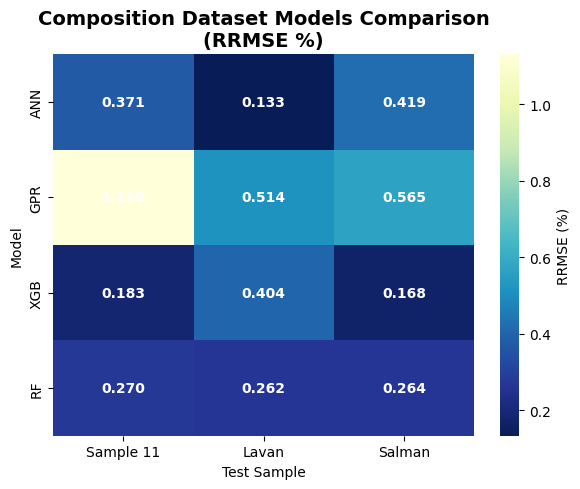

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    rrmse_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu_r",
    cbar_kws={"label": "RRMSE (%)"},
    annot_kws={"color":"white","weight":"bold"}
)

plt.title(
    "Composition Dataset Models Comparison\n(RRMSE %)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Model")
plt.xlabel("Test Sample")

plt.tight_layout()
plt.show()

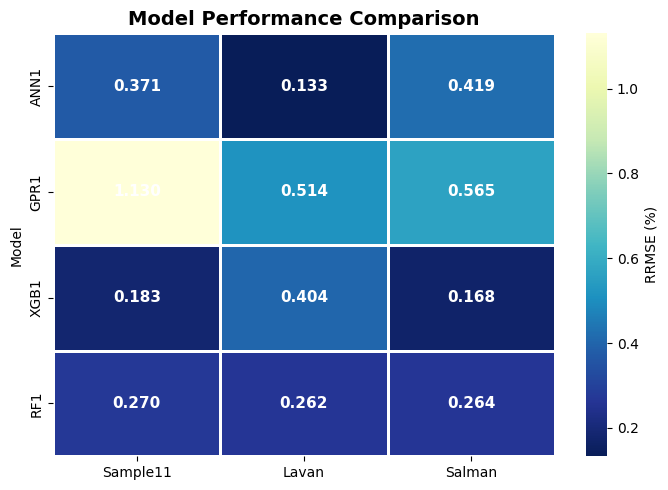

In [8]:
metrics_df = pd.DataFrame({

    "Model": ["ANN1","GPR1","XGB1","RF1"],

    "Sample11": [
        0.370828,   # ANN11
        1.130255,   # GPR1
        0.183417,   # XGB1
        0.270138    # RF1
    ],

    "Lavan": [
        0.132891,   # ANN1
        0.514142,   # GPR1
        0.404175,   # XGB1
        0.262388    # RF1
    ],

    "Salman": [
        0.418827,   # ANN1
        0.564896,   # GPR1
        0.168186,   # XGB1
        0.264221    # RF1
    ]


})
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = metrics_df.set_index("Model")

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu_r",
    linewidths=1,
    cbar_kws={"label":"RRMSE (%)"},
    annot_kws={
        "color":"white",
        "weight":"bold",
        "size":11
    }
)

plt.title(
    "Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

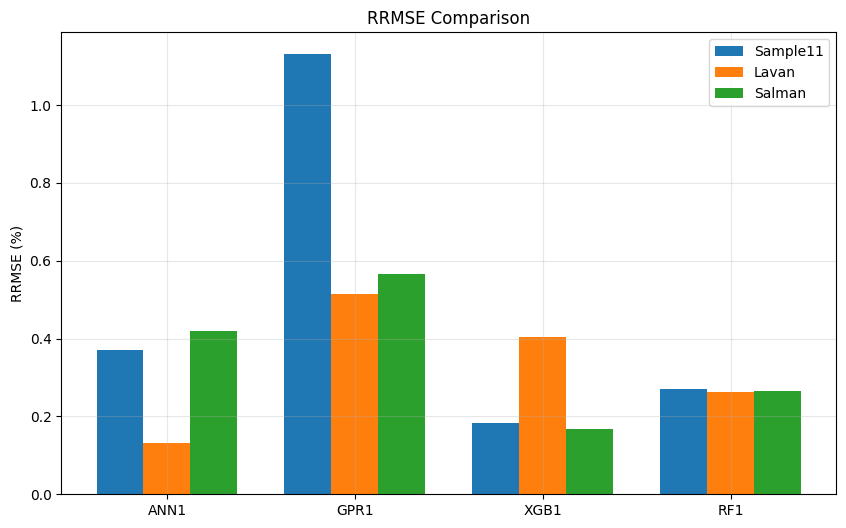

In [9]:
import matplotlib.pyplot as plt
import numpy as np

models = metrics_df["Model"]

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(10,6))

plt.bar(
    x-width,
    metrics_df["Sample11"],
    width,
    label="Sample11"
)

plt.bar(
    x,
    metrics_df["Lavan"],
    width,
    label="Lavan"
)

plt.bar(
    x+width,
    metrics_df["Salman"],
    width,
    label="Salman"
)

plt.xticks(x, models)

plt.ylabel("RRMSE (%)")

plt.title("RRMSE Comparison")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

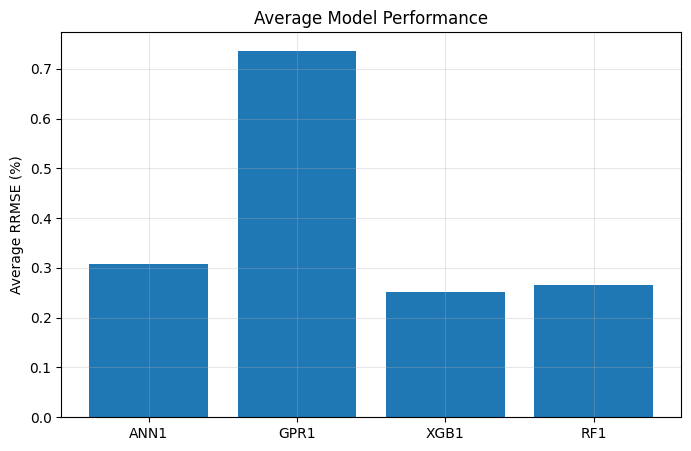

In [10]:
metrics_df["Average"] = metrics_df[
    ["Sample11","Lavan","Salman"]
].mean(axis=1)

plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Model"],
    metrics_df["Average"]
)

plt.ylabel("Average RRMSE (%)")

plt.title("Average Model Performance")

plt.grid(alpha=0.3)

plt.show()

  Model  Wins
0  ANN1     1
1  GPR1     0
2  XGB1     2
3   RF1     0


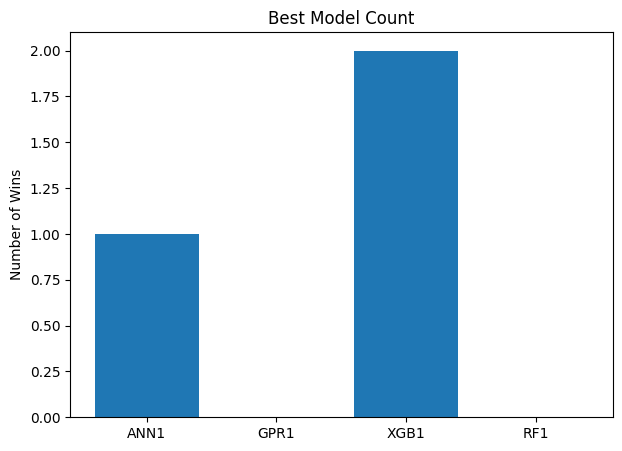

In [11]:
wins = {
    "ANN1":0,
    "GPR1":0,
    "XGB1":0,
    "RF1":0
}

for col in ["Sample11","Lavan","Salman"]:

    winner = metrics_df.loc[
        metrics_df[col].idxmin(),
        "Model"
    ]

    wins[winner] += 1

wins_df = pd.DataFrame({

    "Model": list(wins.keys()),
    "Wins": list(wins.values())

})

print(wins_df)

plt.figure(figsize=(7,5))

plt.bar(
    wins_df["Model"],
    wins_df["Wins"]
)

plt.ylabel("Number of Wins")

plt.title("Best Model Count")

plt.show()

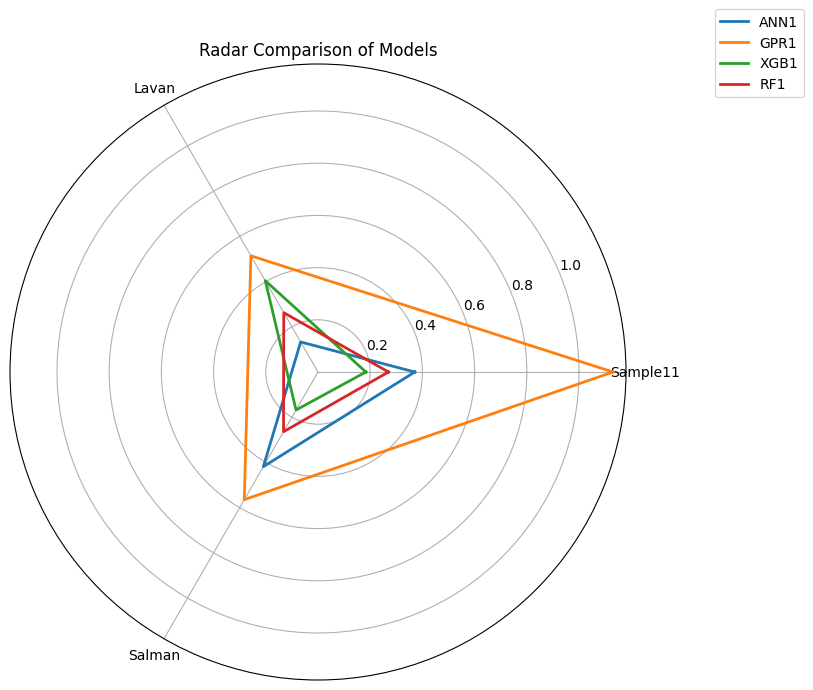

In [12]:
import numpy as np
import matplotlib.pyplot as plt

categories = [
    "Sample11",
    "Lavan",
    "Salman"
]

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for _, row in metrics_df.iterrows():

    values = [
        row["Sample11"],
        row["Lavan"],
        row["Salman"]
    ]

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(categories)

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.3,1.1)
)

plt.title("Radar Comparison of Models")

plt.show()